This file is to make the model

In [2]:
import json
import numpy as np
import pandas as pd

from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "ML" else Path.cwd().resolve()
LABELS_PATH = PROJECT_ROOT / "logs" / "labeled_data" / "labels0_5000.json"
print(Path.cwd())
print(LABELS_PATH.resolve())
print(LABELS_PATH.exists())

# Load the JSON file
fileName = 'labels0_5000.json'

# directory is logs/labeled_data
directory = PROJECT_ROOT / "logs" / "labeled_data"
filePath = directory / fileName
print(f"Loading data from {filePath}...")
with filePath.open('r', encoding='utf-8-sig') as f:
    data = json.load(f)
# Convert to DataFrame for better visualization
df  = pd.DataFrame(data)

# Display basic information
print("Data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print("\nColumn names:")
print(df.columns.tolist())


e:\Pradyuman\Programming\Random projects\Screen analysis
E:\Pradyuman\Programming\Random projects\Screen analysis\logs\labeled_data\labels0_5000.json
True
Loading data from ./logs/labeled_data/labels0_5000.json...
Data shape: (5000, 8)

First few rows:
            app                                              title  \
0    python.exe  Select C:\Users\SCL\AppData\Local\Programs\Pyt...   
1    python.exe  C:\Users\SCL\AppData\Local\Programs\Python\Pyt...   
2  OneDrive.exe                                                      
3    msedge.exe  YouTube and 6 more pages - Profile 1 - Microso...   
4      Code.exe  activity_tracker.py - Screen analysis (Workspa...   

                        start                         end  duration_seconds  \
0  2025-11-24T16:53:32.788037  2025-11-24T16:53:36.629519               3.0   
1  2025-11-24T20:18:21.874945  2025-11-24T20:18:37.886076              16.0   
2  2025-11-24T20:18:37.886076  2025-11-24T20:18:38.918568               1.0   
3  2025-11

Going to USE TD-IDF and Logistic regression
TD-IDF will convert text to numbers to classify 
Logisitic regression will classify using numerical data

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [4]:
df["title"] = df["title"].fillna("")
df["app"] = df["app"].fillna("")

df["start"] = pd.to_datetime(df["start"], errors="coerce")
df["hour"] = df["start"].dt.hour
df["day_of_week"] = df["start"].dt.dayofweek

df["duration_seconds"] = pd.to_numeric(df["duration_seconds"], errors="coerce")

if "idle_time_seconds" in df.columns:
    df["idle_time_seconds"] = pd.to_numeric(df["idle_time_seconds"], errors="coerce")
else:
    df["idle_time_seconds"] = pd.to_numeric(df["idle_time"], errors="coerce")

feature_columns = [
    "title",
    "app",
    "duration_seconds",
    "idle_time_seconds",
    "hour",
    "day_of_week",
]
target_column = "label"

df[feature_columns + [target_column]].head()


,title,app,duration_seconds,idle_time_seconds,hour,day_of_week,label
0,Select C:\Users\SCL\AppData\Local\Programs\Pyt...,python.exe,3.0,1.328,16,0,Productivity
1,C:\Users\SCL\AppData\Local\Programs\Python\Pyt...,python.exe,16.0,16.000,20,0,Productivity
2,,OneDrive.exe,1.0,1.000,20,0,Other
3,YouTube and 6 more pages - Profile 1 - Microso...,msedge.exe,8.0,3.188,20,0,brainless Entertainment
4,activity_tracker.py - Screen analysis (Workspa...,Code.exe,29.0,0.000,22,0,Productivity


In [5]:
X = df[feature_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 4000
Test size: 1000


In [6]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("title_tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), "title"),
        ("app_ohe", OneHotEncoder(handle_unknown="ignore"), ["app"]),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            ["duration_seconds", "idle_time_seconds", "hour", "day_of_week"],
        ),
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('title_tfidf', ...), ('app_ohe', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [7]:
import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "ML" else Path.cwd().resolve()
model_path = PROJECT_ROOT / "ML" / "app_category_model.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)

with model_path.open("wb") as f:
    pickle.dump(model, f)

print(f"Saved model to {model_path.resolve()}")


Saved model to E:\Pradyuman\Programming\Random projects\Screen analysis\models\app_category_model.pkl


In [8]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

wrong_predictions = X_test.loc[y_test != y_pred].copy()
wrong_predictions.insert(0, "actual_label", y_test.loc[wrong_predictions.index].values)
wrong_predictions.insert(1, "predicted_label", y_pred[y_test != y_pred])
wrong_predictions["start"] = df.loc[wrong_predictions.index, "start"]
wrong_predictions.sort_index()


Accuracy: 0.949

                         precision    recall  f1-score   support

          Communication       1.00      0.99      1.00       165
          Entertainment       0.98      0.83      0.90       123
                 Gaming       0.97      0.97      0.97        31
                  Other       0.99      0.99      0.99       158
           Productivity       0.98      0.87      0.92        53
                  Songs       0.86      0.78      0.82        64
brainless Entertainment       0.91      0.99      0.95       406

               accuracy                           0.95      1000
              macro avg       0.96      0.92      0.93      1000
           weighted avg       0.95      0.95      0.95      1000



,actual_label,predicted_label,title,app,duration_seconds,idle_time_seconds,hour,day_of_week,start
32,Entertainment,brainless Entertainment,(1) CHELSEA STUN BARCELONA! ?? UCL Today BEST ...,msedge.exe,40.891,40.891,7,2,2025-11-26 07:43:16.426304
34,Entertainment,brainless Entertainment,(1) CHELSEA STUN BARCELONA! ?? UCL Today BEST ...,msedge.exe,2.000,0.000,7,2,2025-11-26 07:55:24.883620
35,Entertainment,brainless Entertainment,(1) Est�v�o shines as Chelsea sink Barcelona! ...,msedge.exe,6.000,0.000,7,2,2025-11-26 07:55:26.884832
38,Entertainment,brainless Entertainment,(1) Est�v�o shines as Chelsea sink Barcelona! ...,msedge.exe,3.000,0.000,7,2,2025-11-26 07:55:42.892497
45,Entertainment,brainless Entertainment,(1) Est�v�o shines as Chelsea sink Barcelona! ...,msedge.exe,3.813,3.813,7,2,2025-11-26 07:55:55.902111
46,Entertainment,brainless Entertainment,(1) Est�v�o shines as Chelsea sink Barcelona! ...,msedge.exe,46.000,0.000,8,2,2025-11-26 08:15:56.588163
96,Other,brainless Entertainment,Extensions,msedge.exe,1.000,0.000,8,2,2025-11-26 08:52:45.888017
108,Songs,brainless Entertainment,(1) B�JET - i wasn't enough for u - YouTube an...,msedge.exe,2.000,0.000,9,2,2025-11-26 09:16:45.745673
207,brainless Entertainment,Gaming,Special Offers,steamwebhelper.exe,2.000,0.000,20,6,2026-01-04 20:55:20.473346
385,Entertainment,Songs,Spotify Premium,Spotify.exe,2.000,0.000,9,1,2026-02-03 09:51:22.531575


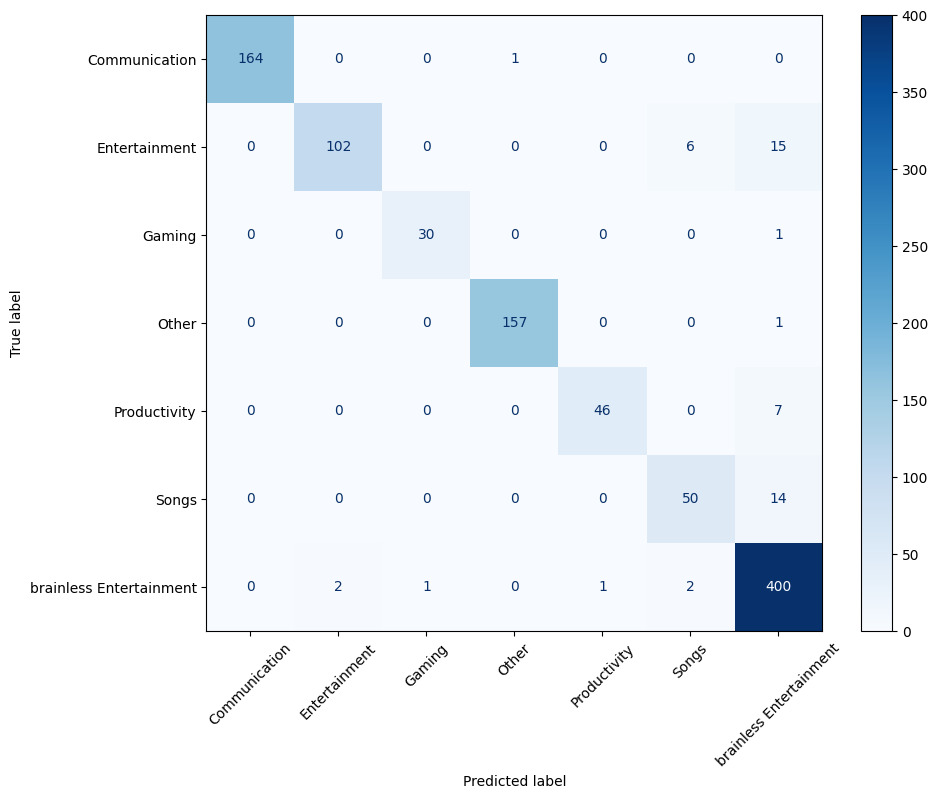

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")
plt.show()
